In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
C = data_.C_int.differentiate("time",datetime_unit="s")
data["C"]=(['time', 'x', 'y'],  C.data)

# Barotropic velocity

In [14]:
# read data
Data = xr.open_dataset(datafilepath+datafilename)

# grid info
import mat73
grid = mat73.loadmat('/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/mfiles/SUNTANS_grid.mat', only_include=['Nk', 'Nx', 'Ny', 'Depth', 'INPUT']) 

Nx = grid['Nx'].astype('int')
Ny = grid['Ny'].astype('int')
Nk = grid['Nk'].astype('int')
Nc = Nx*Ny
# Depth = np.reshape(grid['Depth'].astype('int'), (Nx, Ny), order='F')
Depth = np.reshape(grid['Depth'], (Nx, Ny), order='F')

xv = np.reshape(Data.xv.data, (Nx, Ny), order='F')
yv = np.reshape(Data.yv.data, (Nx, Ny), order='F')

In [15]:
U = np.reshape(Data.Ubt.data, (len(Data.time), Nx, Ny), order='F')
V = np.reshape(Data.Vbt.data, (len(Data.time), Nx, Ny), order='F')

In [16]:
data["U"]=(['time', 'x', 'y'],  U)
data["V"]=(['time', 'x', 'y'],  V)

# Scale time

In [6]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# Island center & Shoaling depth

In [7]:
lambdaM2=70.1e3
l_sponge = 20e3
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [8]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [ ]:
C = data_.C_int.differentiate("time",datetime_unit="s")
data["C"]=(['time', 'x', 'y'],  C.data)

In [1]:
count = 0
for idx_t_data in np.arange(39,100+1,3):
    
    idx_t_ = count+13
    printf("idx_t_", "idx_t_data")
    count+=1

NameError: name 'np' is not defined

# Plot energy evolution

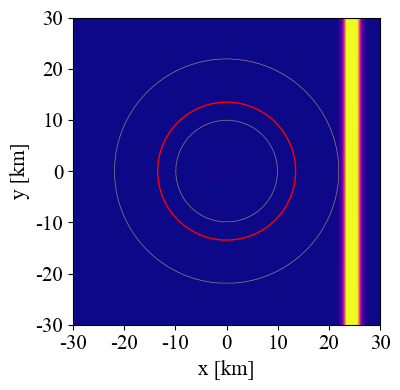

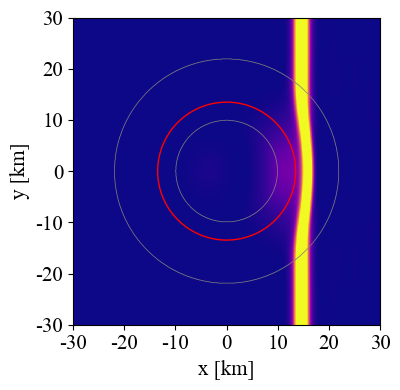

In [17]:
for idx_t in [39, 51]:

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
    im1 = data_.dEp0[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=5, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    ax.set_xlim([x_c-30000, x_c+30000])
    ax.set_ylim([y_c-30000, y_c+30000])
    ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
    ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
    ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEp0_overhead_summer_nof_t{idx_t}.png", transparent = True, dpi=300)

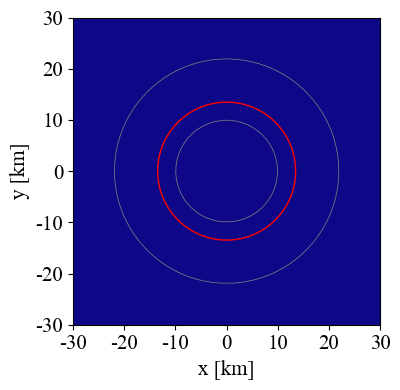

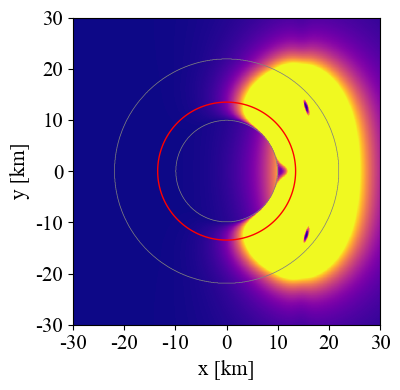

In [10]:
for idx_t in [39, 51]:

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
    im1 = data_.dEk0[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=5, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    ax.set_xlim([x_c-30000, x_c+30000])
    ax.set_ylim([y_c-30000, y_c+30000])
    ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
    ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
    ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEk0_overhead_summer_nof_t{idx_t}.png", transparent = True, dpi=300)

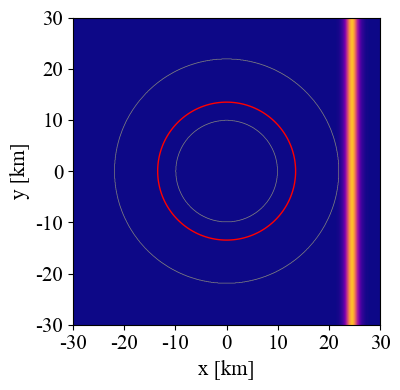

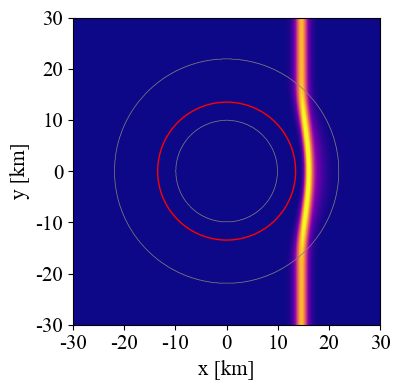

In [11]:
for idx_t in [39, 51]:

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
    im1 = data_.dEp_prime[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=1e4, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    # ax.text(x_c-30000+3000, y_c+25000, f't = {np.round(t_nondim[idx_t],2)}', fontsize=20)
    ax.set_xlim([x_c-30000, x_c+30000])
    ax.set_ylim([y_c-30000, y_c+30000])
    ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
    ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
    ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEp_prime_overhead_summer_nof_t{idx_t}.png", transparent = True, dpi=300)

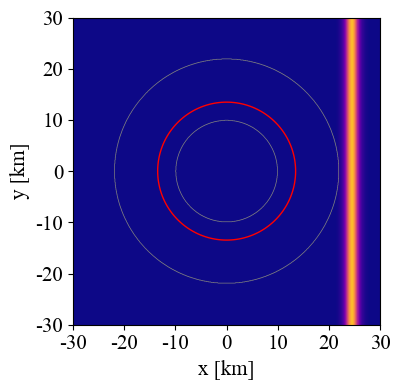

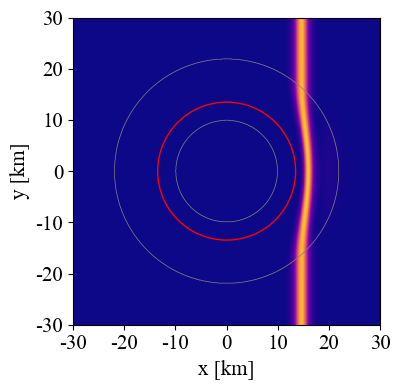

In [12]:
for idx_t in [39, 51]:

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
    im1 = data_.dEk_prime[idx_t,:,:].T.plot.pcolormesh(ax=ax, vmax=1e4, vmin=0, cmap=cm.plasma, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    
    ax.set_xlim([x_c-30000, x_c+30000])
    ax.set_ylim([y_c-30000, y_c+30000])
    ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
    ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
    ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    plt.savefig(outfilepath+ f"dEk_prime_overhead_summer_nof_t{idx_t}.png", transparent = True, dpi=300)

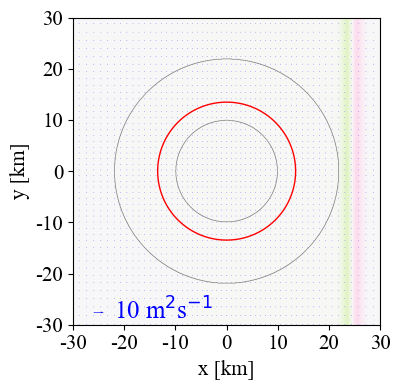

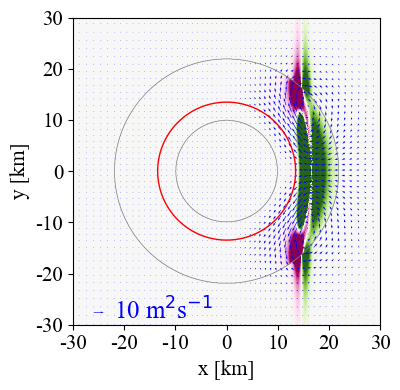

In [19]:
idx_t_ = [13, 17]
count = 0
for idx_t in [39, 51]:

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
    im1 = (data.C[idx_t,:,:]+data_Cadv.Ah0[idx_t_[count],:,:]).T.plot.pcolormesh(ax=ax, vmax=.05, vmin=-.05, cmap=cm.PiYG_r, add_colorbar=False)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_bottom], colors='0.5', linewidths=.5)
    ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_shoal], colors='r', linewidths=1)
    Q = ax.quiver(data.x.data[::20], data.y.data[::20], (data.U.data[idx_t,::20,::20]*data_.depth[::20,::20].data).T, (data.V.data[idx_t,::20,::20]*data_.depth[::20,::20].data).T, scale=1e2, scale_units='inches', width=2e-3, color='b')
    qk = ax.quiverkey(Q, 0.1, .04, 1e1, r'10 m$^2$s$^{-1}$', labelpos='E', fontproperties={'size':18}, labelcolor='b')
   
    ax.set_xlim([x_c-30000, x_c+30000])
    ax.set_ylim([y_c-30000, y_c+30000])
    ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
    ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
    ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
    ax.set_aspect('equal')
    ax.set_xlabel('x [km]', fontsize=15)
    ax.set_ylabel('y [km]', fontsize=15)
    ax.set_title(f'')
    ax.tick_params(axis='both', which='major', labelsize=15)
    plt.rcParams["font.family"] = "Times New Roman"
    plt.tight_layout()
    
    count+=1
    
    plt.savefig(outfilepath+ f"C_overhead_summer_nof_t{idx_t}.png", transparent = True, dpi=300)